# Деревья решений, градиентный бустинг и случайный лес

# 1.1. Анализ датасета

In [ ]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
! kaggle datasets download suleymansulak/obesity-dataset -f Obesity_Dataset.arff

Dataset URL: https://www.kaggle.com/datasets/suleymansulak/obesity-dataset
License(s): CC-BY-NC-SA-4.0
  0% 0.00/52.8k [00:00<?, ?B/s]
100% 52.8k/52.8k [00:00<00:00, 41.0MB/s]


In [ ]:
arff_file = arff.loadarff('Obesity_Dataset.arff')

In [ ]:
arff_file

(array([(2., 18., 155., 2., 2., 3., 1., 3., 2., 1., 2., 3., 3., 4., b'2'),
        (2., 18., 158., 2., 2., 3., 1., 1., 2., 1., 2., 1., 3., 3., b'2'),
        (2., 18., 159., 2., 2., 2., 1., 3., 2., 3., 2., 2., 3., 4., b'2'),
        ...,
        (2., 52., 162., 1., 2., 1., 3., 4., 1., 3., 1., 4., 1., 1., b'4'),
        (2., 53., 168., 2., 1., 1., 3., 4., 1., 2., 2., 2., 1., 1., b'4'),
        (2., 54., 170., 1., 1., 1., 3., 4., 1., 3., 2., 4., 3., 1., b'4')],
       dtype=[('Sex', '<f8'), ('Age', '<f8'), ('Height', '<f8'), ('Overweight_Obese_Family', '<f8'), ('Consumption_of_Fast_Food', '<f8'), ('Frequency_of_Consuming_Vegetables', '<f8'), ('Number_of_Main_Meals_Daily', '<f8'), ('Food_Intake_Between_Meals', '<f8'), ('Smoking', '<f8'), ('Liquid_Intake_Daily', '<f8'), ('Calculation_of_Calorie_Intake', '<f8'), ('Physical_Excercise', '<f8'), ('Schedule_Dedicated_to_Technology', '<f8'), ('Type_of_Transportation_Used', '<f8'), ('Class', 'S1')]),
 Dataset: Obesity_Dataset
 	Sex's type is nume

In [ ]:
data = pd.DataFrame(arff_file[0])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Sex                                1610 non-null   float64
 1   Age                                1610 non-null   float64
 2   Height                             1610 non-null   float64
 3   Overweight_Obese_Family            1610 non-null   float64
 4   Consumption_of_Fast_Food           1610 non-null   float64
 5   Frequency_of_Consuming_Vegetables  1610 non-null   float64
 6   Number_of_Main_Meals_Daily         1610 non-null   float64
 7   Food_Intake_Between_Meals          1610 non-null   float64
 8   Smoking                            1610 non-null   float64
 9   Liquid_Intake_Daily                1610 non-null   float64
 10  Calculation_of_Calorie_Intake      1610 non-null   float64
 11  Physical_Excercise                 1610 non-null   float

In [ ]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='count'>

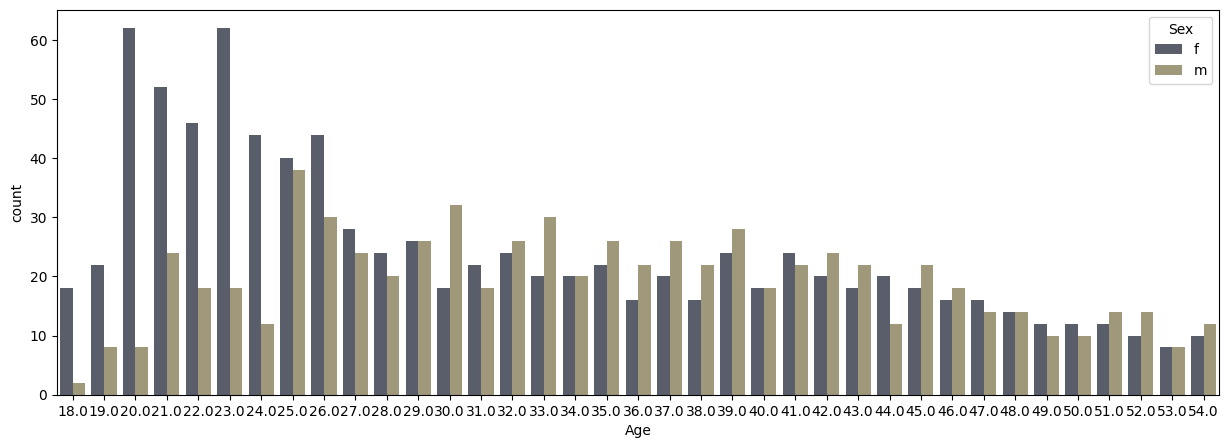

In [ ]:
fig = plt.figure(figsize=(15, 5))
sns.countplot(x='Age', hue="Sex", data=data, palette="cividis")

<Axes: xlabel='Age', ylabel='count'>

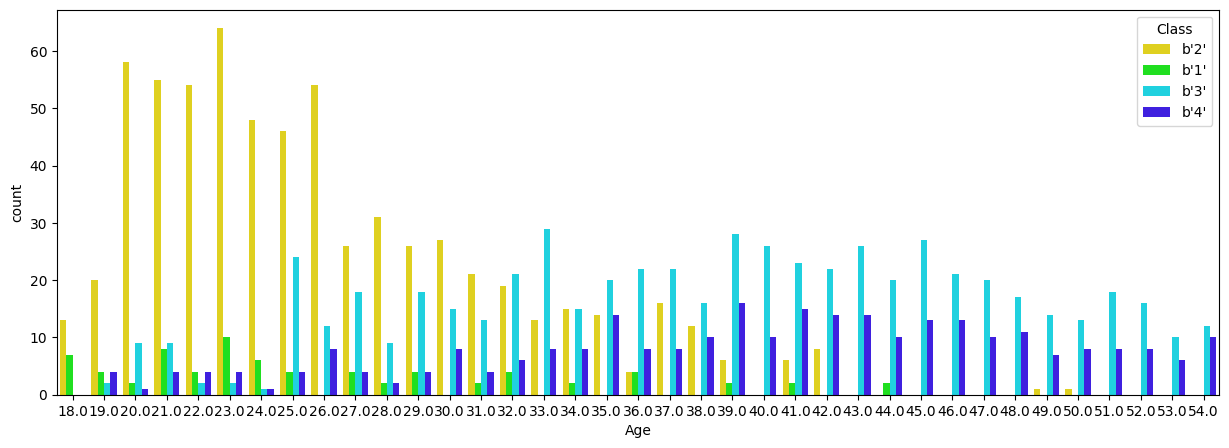

In [ ]:
fig = plt.figure(figsize=(15, 5))
sns.countplot(x='Age', hue="Class", data=data, palette="gist_rainbow")

По графику видно, что большое количество людей от 18 до 30 имеют недовес.

Нормальный вес в основном у людей до 30.

Избыточный вес и ожирение встречаются в основном у людей старше 32 лет.



---



"Obesity Dataset"

Датасет основан на онлайн-опросе, который проводился среди 1610 человек.

Всего 15 переменных. Из них:

- 13 категориальных
- 2 количественные (возраст, рост)

dtypes: float64(14), object(1)

Признаков с пропущенными значениями нет.

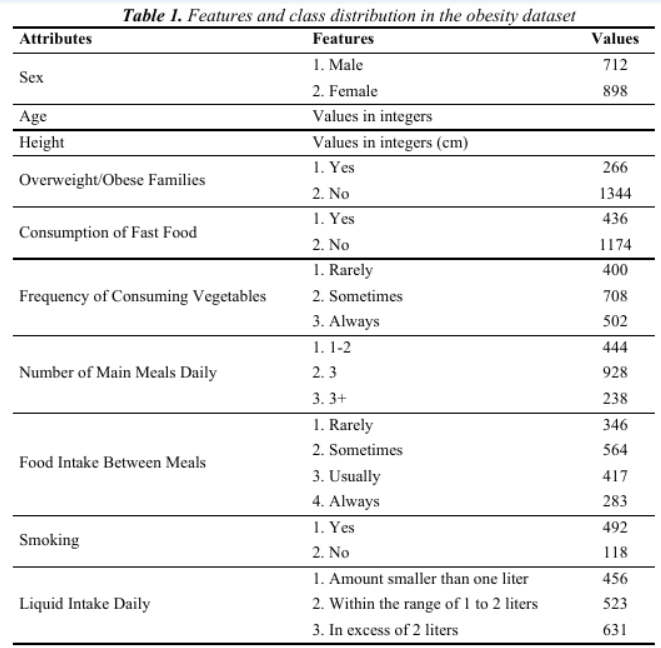

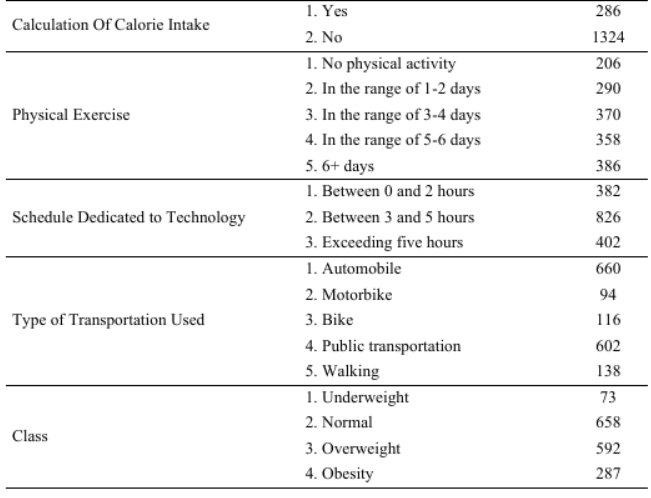



---



# 1.2. Построим, визуализируем и оценим дерево решений (для хорошей визуализации рассмотрим дерево глубины 3)

In [ ]:
data.head(3)

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Class
0,2.0,18.0,155.0,2.0,2.0,3.0,1.0,3.0,2.0,1.0,2.0,3.0,3.0,4.0,b'2'
1,2.0,18.0,158.0,2.0,2.0,3.0,1.0,1.0,2.0,1.0,2.0,1.0,3.0,3.0,b'2'
2,2.0,18.0,159.0,2.0,2.0,2.0,1.0,3.0,2.0,3.0,2.0,2.0,3.0,4.0,b'2'


In [ ]:
data['Sex'] = data['Sex'].replace(
    [1, 2],
    ['m', 'f']
)

In [ ]:
X = pd.get_dummies(data.drop(columns=['Class']))
Y_base = data['Class']

display(X.head(3))
display(Y_base.head(3))

,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Sex_f,Sex_m
0,18.0,155.0,2.0,2.0,3.0,1.0,3.0,2.0,1.0,2.0,3.0,3.0,4.0,True,False
1,18.0,158.0,2.0,2.0,3.0,1.0,1.0,2.0,1.0,2.0,1.0,3.0,3.0,True,False
2,18.0,159.0,2.0,2.0,2.0,1.0,3.0,2.0,3.0,2.0,2.0,3.0,4.0,True,False


,Class
0,b'2'
1,b'2'
2,b'2'


In [ ]:
Y = []
for i in Y_base:
  if str(i) == "b'2'":
    Y.append(2)
  elif str(i) == "b'3'":
    Y.append(3)
  elif str(i) == "b'4'":
    Y.append(4)
  else:
    Y.append(1)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=23)



---



In [ ]:
dtc = DTC(
    max_depth=11,
    random_state=35
)

In [ ]:
dtc.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=11, random_state=35)

In [ ]:
print(classification_report(
    Y_test, dtc.predict(X_test),
    target_names=[
        'Underweight', 'Normal', 'Overweight', 'Obesity'
        ], digits=4
    ))

              precision    recall  f1-score   support

 Underweight     0.8182    0.7500    0.7826        12
      Normal     0.9167    0.8897    0.9030       136
  Overweight     0.7966    0.8468    0.8210       111
     Obesity     0.8361    0.8095    0.8226        63

    accuracy                         0.8540       322
   macro avg     0.8419    0.8240    0.8323       322
weighted avg     0.8558    0.8540    0.8545       322



In [ ]:
from matplotlib import pyplot as plt
from sklearn import tree

[Text(0.5, 0.9, 'Age <= 31.5\ngini = 0.664\nsamples = 1288\nvalue = [61.0, 522.0, 481.0, 224.0]\nclass = Normal'),
 Text(0.25, 0.7, 'Frequency_of_Consuming_Vegetables <= 2.5\ngini = 0.493\nsamples = 625\nvalue = [47, 427, 108, 43]\nclass = Normal'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Number_of_Main_Meals_Daily <= 2.5\ngini = 0.603\nsamples = 352\nvalue = [22, 197, 90, 43]\nclass = Normal'),
 Text(0.0625, 0.3, 'Sex_m <= 0.5\ngini = 0.553\nsamples = 313\nvalue = [20, 189, 86, 18]\nclass = Normal'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'Frequency_of_Consuming_Vegetables <= 1.5\ngini = 0.534\nsamples = 39\nvalue = [2.0, 8.0, 4.0, 25.0]\nclass = Obesity'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'Physical_Excercise <= 1.5\ngini = 0.277\nsamples = 273\nvalue = [25, 230, 18, 0]\nclass = Normal'),
 Text(0.3125, 0.3, 'Smoking <= 1.5\ngini = 0.464\nsamples = 74\nvalue = [2

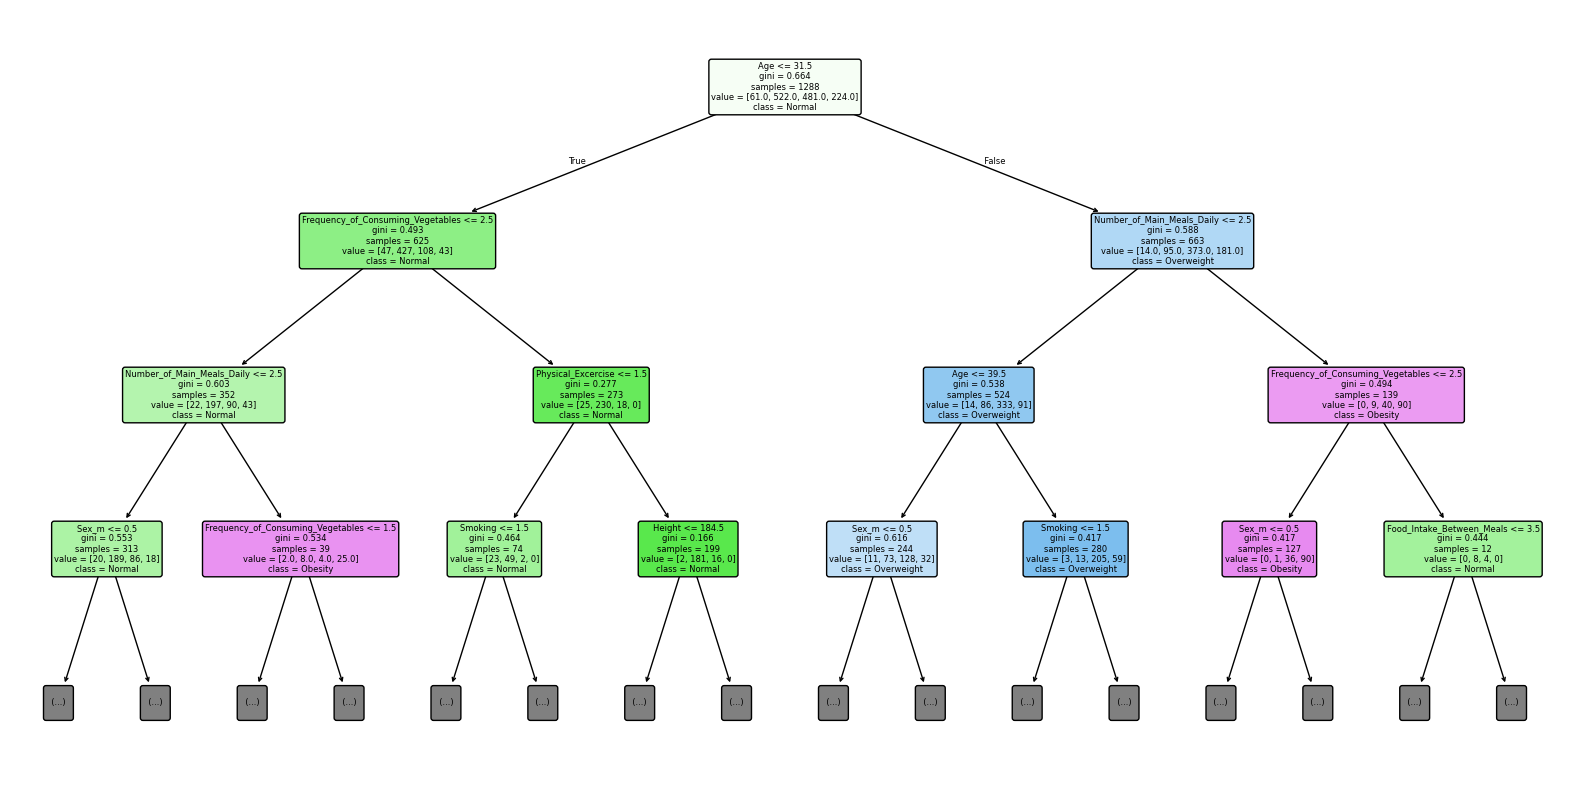

In [ ]:
fig = plt.figure(figsize=(20, 10))
tree.plot_tree(
    dtc,
    feature_names=X_train.columns,
    class_names=[
        'Underweight', 'Normal', 'Overweight', 'Obesity'
        ],
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=6
    )



---



**Вывод**: мы проанализировали выбранный датасет, выделили кол-во категориальных и количественных признаков. Применили дерево решений для классификаци и получили качество классификации почти в 86% (0.8545) по среднему взвешенному. И визуализировали часть дерева.



---



---



# 2.1. Построим зависимость качества решения (на обучении и скользящем контроле) от числа листьев дерева.

In [ ]:
max_leaf_nodes_values = range(4, 250)

train_accuracies = []
test_accuracies = []
cross_val_scores = []

In [ ]:
max_train, max_test, max_cross = 0, 0, 0
train_leaf, test_leaf, cross_leaf = 0, 0, 0

for max_leaf_nodes in max_leaf_nodes_values:
    model = DTC(
        max_leaf_nodes=max_leaf_nodes,
        max_depth=11,
        random_state=35
        )
    model.fit(X_train, Y_train)

    train_accuracy = accuracy_score(Y_train, model.predict(X_train))
    train_accuracies.append(train_accuracy)

    test_accuracy = accuracy_score(Y_test, model.predict(X_test))
    test_accuracies.append(test_accuracy)

    cross_val_score_mean = np.mean(cross_val_score(model, X, Y))
    cross_val_scores.append(cross_val_score_mean)

    if train_accuracy > max_train:
      max_train = train_accuracy
      train_leaf = max_leaf_nodes

    if test_accuracy > max_test:
      max_test = test_accuracy
      test_leaf = max_leaf_nodes

    if cross_val_score_mean > max_cross:
      max_cross = cross_val_score_mean
      cross_leaf = max_leaf_nodes

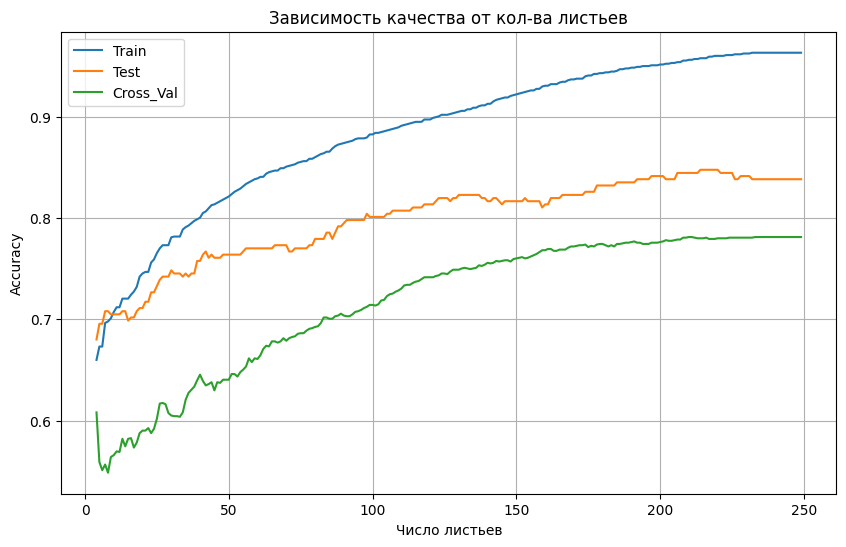

Лучшее качество на трейне (0.964) показывает при кол-ве листьев = 232.
Лучшее качество на тесте (0.848) показывает при кол-ве листьев = 214.
Лучшее качество на валидации (0.781) показывает при кол-ве листьев = 233.


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(max_leaf_nodes_values, train_accuracies, label='Train')
plt.plot(max_leaf_nodes_values, test_accuracies, label='Test')
plt.plot(max_leaf_nodes_values, cross_val_scores, label='Cross_Val')
plt.xlabel('Число листьев')
plt.ylabel('Accuracy')
plt.title('Зависимость качества от кол-ва листьев')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print(f'Лучшее качество на трейне ({max_train:.3f}) показывает при кол-ве листьев = {train_leaf}.')
print(f'Лучшее качество на тесте ({max_test:.3f}) показывает при кол-ве листьев = {test_leaf}.')
print(f'Лучшее качество на валидации ({max_cross:.3f}) показывает при кол-ве листьев = {cross_leaf}.')

# 2.2. Рассмотрим разные критерии ветвления

In [ ]:
criteria = ['gini', 'entropy', 'log_loss']
tr = []
ts = []
cr = []

for criter in criteria:
  dtc_2 = DTC(
      criterion=criter,
      max_depth=11,
      random_state=35
  )
  dtc_2.fit(X_train, Y_train)

  tr.append(accuracy_score(Y_train, dtc_2.predict(X_train)))
  ts.append(accuracy_score(Y_test, dtc_2.predict(X_test)))
  cr.append(np.mean(cross_val_score(dtc_2, X, Y)))

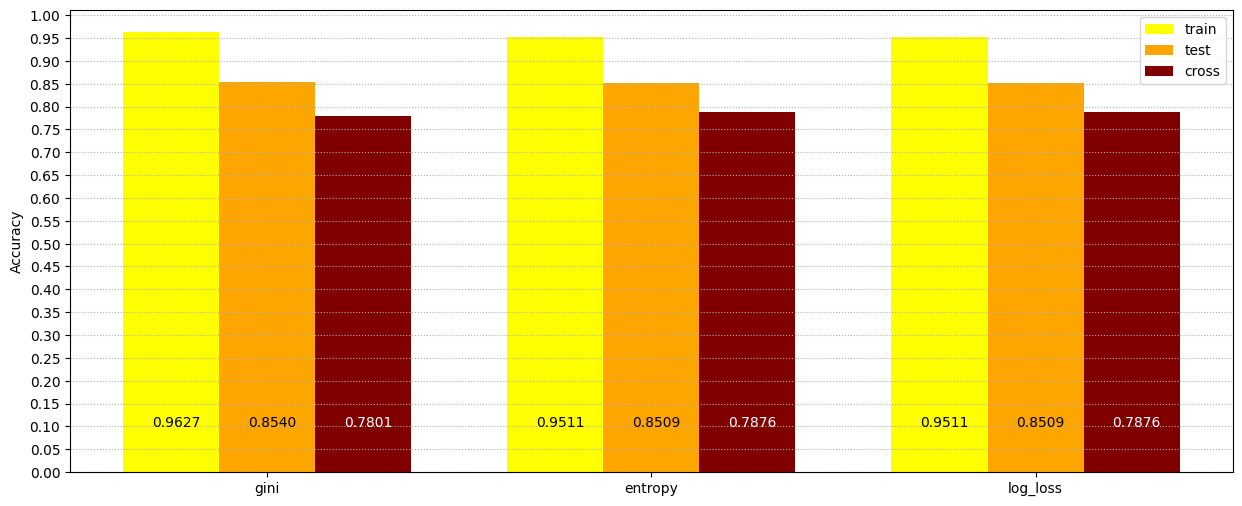

In [ ]:
plt.figure(figsize=(15, 6))
barWidth = 0.25

br1 = np.arange(len(tr))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]

plt.bar(br1, tr, color ='yellow', width = barWidth, label ='train')
plt.bar(br2, ts, color ='orange', width = barWidth, label ='test')
plt.bar(br3, cr, color ='maroon', width = barWidth, label ='cross')

n = 0
for i in br1:
    plt.text(i-0.05, 0.1, str("%.4f" % tr[n]))
    n += 1

n = 0
for i in br2:
    plt.text(i-0.05, 0.1, str("%.4f" % ts[n]))
    n += 1

n = 0
for i in br3:
    plt.text(i-0.05, 0.1, str("%.4f" % cr[n]), color='w')
    n += 1

plt.ylabel('Accuracy')
plt.xticks([r + barWidth for r in range(len(tr))], criteria)
plt.yticks(np.arange(0, 1.05, 0.05))

plt.legend(loc='best')
plt.grid(True, axis = 'y', linestyle=':')
plt.show()



---



**Вывод**:

Зависимость от числа листьев:

- Лучшее качество на тесте (0.848) показывает при кол-ве листьев = 214.
- Лучшее качество на валидации (0.781) показывает при кол-ве листьев = 233.

Критерии ветвления:

результаты на тесте и валидации соответственно сопоставимы и разница очень мала.



---



---



# 3.1. Применим модель градиентного бустинга

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier as GBC

In [ ]:
gb_param = GBC(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],  # default=100
    'learning_rate': [0.01, 0.1, 0.2],  # default=0.1
    'max_depth': [3, 5, 7],  # default=3
    'subsample': [0.8, 1.0]  # default=1.0
}

grid_search = GridSearchCV(
    estimator=gb_param,
    param_grid=param_grid,
    scoring='accuracy'
)
grid_search.fit(X_train, Y_train)

best_params = grid_search.best_params_
print(f'Best Parameters: {best_params}')

best_gb = grid_search.best_estimator_
test_pred = best_gb.predict(X_test)
test_accuracy = accuracy_score(Y_test, test_pred)
print(f'Test Accuracy: {test_accuracy:.4f}')

Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Test Accuracy: 0.8820


Выбор subsample < 1.0 приводит к уменьшению дисперсии (variance) и увеличению смещения (bias).

У глубоких деревьев большой разброс (вар).

У неглубоких (2-5) небольшой разброс и большое смещение.

Наше дерево довольно глубокое, поэтому используем subsample=0.8

In [ ]:
gbc = GBC(
    learning_rate=0.2,
    subsample=0.8,
    max_depth=15,
    random_state=42
).fit(X_train, Y_train)

# Новый раздел

learning_rate=0.2,

subsample=0.8

In [ ]:
depth = range(3,30)
max_acc = 0
dpt = 0

for dt in depth:
  gbc_test_try = GBC(
      learning_rate=0.2,
      subsample=0.8,
      max_depth=dt,
      random_state=42
  ).fit(X_train, Y_train)

  acc = accuracy_score(Y_test, gbc_test_try.predict(X_test))

  if acc > max_acc:
    max_acc = acc
    dpt = dt

  print(f'=== ГЛУБИНА {dt} ===')
  print(acc)

print(f'Лучшее качество ({max_acc:.5f}) при глубине {dpt}')

=== ГЛУБИНА 3 ===
0.8354037267080745
=== ГЛУБИНА 4 ===
0.8695652173913043
=== ГЛУБИНА 5 ===
0.8788819875776398
=== ГЛУБИНА 6 ===
0.8944099378881988
=== ГЛУБИНА 7 ===
0.8819875776397516
=== ГЛУБИНА 8 ===
0.8975155279503105
=== ГЛУБИНА 9 ===
0.8944099378881988
=== ГЛУБИНА 10 ===
0.8819875776397516
=== ГЛУБИНА 11 ===
0.8913043478260869
=== ГЛУБИНА 12 ===
0.8913043478260869
=== ГЛУБИНА 13 ===
0.8975155279503105
=== ГЛУБИНА 14 ===
0.8819875776397516
=== ГЛУБИНА 15 ===
0.9037267080745341
=== ГЛУБИНА 16 ===
0.8913043478260869
=== ГЛУБИНА 17 ===
0.9037267080745341
=== ГЛУБИНА 18 ===
0.8975155279503105
=== ГЛУБИНА 19 ===
0.8913043478260869
=== ГЛУБИНА 20 ===
0.8850931677018633
=== ГЛУБИНА 21 ===
0.9006211180124224
=== ГЛУБИНА 22 ===
0.8913043478260869
=== ГЛУБИНА 23 ===
0.9037267080745341
=== ГЛУБИНА 24 ===
0.8944099378881988
=== ГЛУБИНА 25 ===
0.8881987577639752
=== ГЛУБИНА 26 ===
0.9006211180124224
=== ГЛУБИНА 27 ===
0.8975155279503105
=== ГЛУБИНА 28 ===
0.8913043478260869
=== ГЛУБИНА 29 ===




---



learning_rate=0.2,

subsample=1.0

In [ ]:
depth = range(3,20)
max_acc = 0
dpt = 0

for dt in depth:
  gbc_test_try = GBC(
      learning_rate=0.2,
      subsample=1.0,
      max_depth=dt,
      random_state=42
  ).fit(X_train, Y_train)

  acc = accuracy_score(Y_test, gbc_test_try.predict(X_test))

  if acc > max_acc:
    max_acc = acc
    dpt = dt

  print(f'=== ГЛУБИНА {dt} ===')
  print(acc)

print(f'Лучшее качество ({max_acc:.5f}) при глубине {dpt}')

=== ГЛУБИНА 3 ===
0.8478260869565217
=== ГЛУБИНА 4 ===
0.8571428571428571
=== ГЛУБИНА 5 ===
0.8664596273291926
=== ГЛУБИНА 6 ===
0.8819875776397516
=== ГЛУБИНА 7 ===
0.8975155279503105
=== ГЛУБИНА 8 ===
0.9006211180124224
=== ГЛУБИНА 9 ===
0.8788819875776398
=== ГЛУБИНА 10 ===
0.8819875776397516
=== ГЛУБИНА 11 ===
0.8881987577639752
=== ГЛУБИНА 12 ===
0.8726708074534162
=== ГЛУБИНА 13 ===
0.8416149068322981
=== ГЛУБИНА 14 ===
0.8509316770186336
=== ГЛУБИНА 15 ===
0.84472049689441
=== ГЛУБИНА 16 ===
0.8354037267080745
=== ГЛУБИНА 17 ===
0.8416149068322981
=== ГЛУБИНА 18 ===
0.8385093167701864
=== ГЛУБИНА 19 ===
0.8354037267080745
Лучшее качество (0.90062) при глубине 8




---



learning_rate=0.1,

subsample=0.8

In [ ]:
depth = range(3,20)
max_acc = 0
dpt = 0

for dt in depth:
  gbc_test_try = GBC(
      learning_rate=0.1,
      subsample=0.8,
      max_depth=dt,
      random_state=42
  ).fit(X_train, Y_train)

  acc = accuracy_score(Y_test, gbc_test_try.predict(X_test))

  if acc > max_acc:
    max_acc = acc
    dpt = dt

  print(f'=== ГЛУБИНА {dt} ===')
  print(acc)

print(f'Лучшее качество ({max_acc:.5f}) при глубине {dpt}')

=== ГЛУБИНА 3 ===
0.8416149068322981
=== ГЛУБИНА 4 ===
0.8757763975155279
=== ГЛУБИНА 5 ===
0.8788819875776398
=== ГЛУБИНА 6 ===
0.8819875776397516
=== ГЛУБИНА 7 ===
0.8944099378881988
=== ГЛУБИНА 8 ===
0.8850931677018633
=== ГЛУБИНА 9 ===
0.8850931677018633
=== ГЛУБИНА 10 ===
0.8913043478260869
=== ГЛУБИНА 11 ===
0.8850931677018633
=== ГЛУБИНА 12 ===
0.8975155279503105
=== ГЛУБИНА 13 ===
0.9006211180124224
=== ГЛУБИНА 14 ===
0.8913043478260869
=== ГЛУБИНА 15 ===
0.8850931677018633
=== ГЛУБИНА 16 ===
0.8881987577639752
=== ГЛУБИНА 17 ===
0.8850931677018633
=== ГЛУБИНА 18 ===
0.8913043478260869
=== ГЛУБИНА 19 ===
0.8850931677018633
Лучшее качество (0.90062) при глубине 13


# Новый раздел

In [ ]:
print(classification_report(
    Y_test, gbc.predict(X_test),
    target_names=[
        'Underweight', 'Normal', 'Overweight', 'Obesity'
        ], digits=4
    ))

              precision    recall  f1-score   support

 Underweight     0.9091    0.8333    0.8696        12
      Normal     0.9343    0.9412    0.9377       136
  Overweight     0.8500    0.9189    0.8831       111
     Obesity     0.9444    0.8095    0.8718        63

    accuracy                         0.9037       322
   macro avg     0.9095    0.8757    0.8906       322
weighted avg     0.9063    0.9037    0.9035       322



# 3.2.  Вычислим и визуализируем значимость признаков.

оценки указывают на относительную важность каждого признака в предсказании целевой переменной

In [ ]:
importances = gbc.feature_importances_
feature_imp_df = pd.DataFrame(
    {'Feature': X.columns, 'Importance': importances}
    ).sort_values('Importance', ascending=False)
print(feature_imp_df)

                              Feature  Importance
0                                 Age    0.305787
1                              Height    0.123953
5          Number_of_Main_Meals_Daily    0.093912
4   Frequency_of_Consuming_Vegetables    0.078523
10                 Physical_Excercise    0.076618
6           Food_Intake_Between_Meals    0.047335
8                 Liquid_Intake_Daily    0.043745
12        Type_of_Transportation_Used    0.036834
7                             Smoking    0.033840
11   Schedule_Dedicated_to_Technology    0.031718
2             Overweight_Obese_Family    0.030325
14                              Sex_m    0.029263
3            Consumption_of_Fast_Food    0.028703
13                              Sex_f    0.024420
9       Calculation_of_Calorie_Intake    0.015024


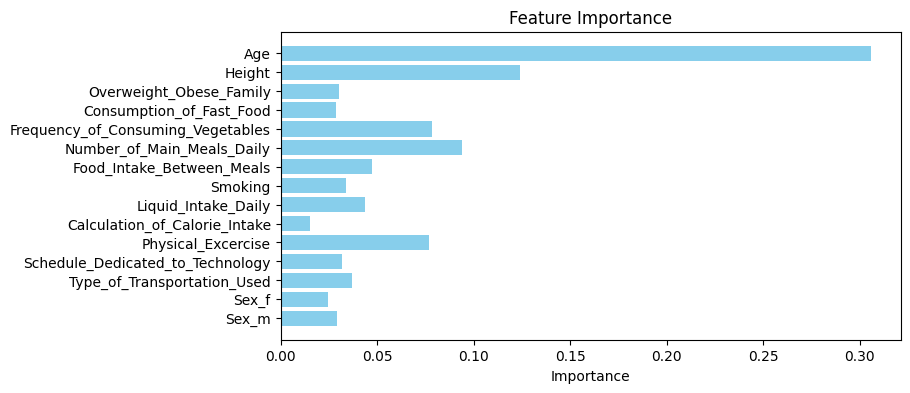

In [ ]:
plt.figure(figsize=(8, 4))
plt.barh(X.columns, importances, color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# 3.3. Визуализируем первые 3 дерева бустинга

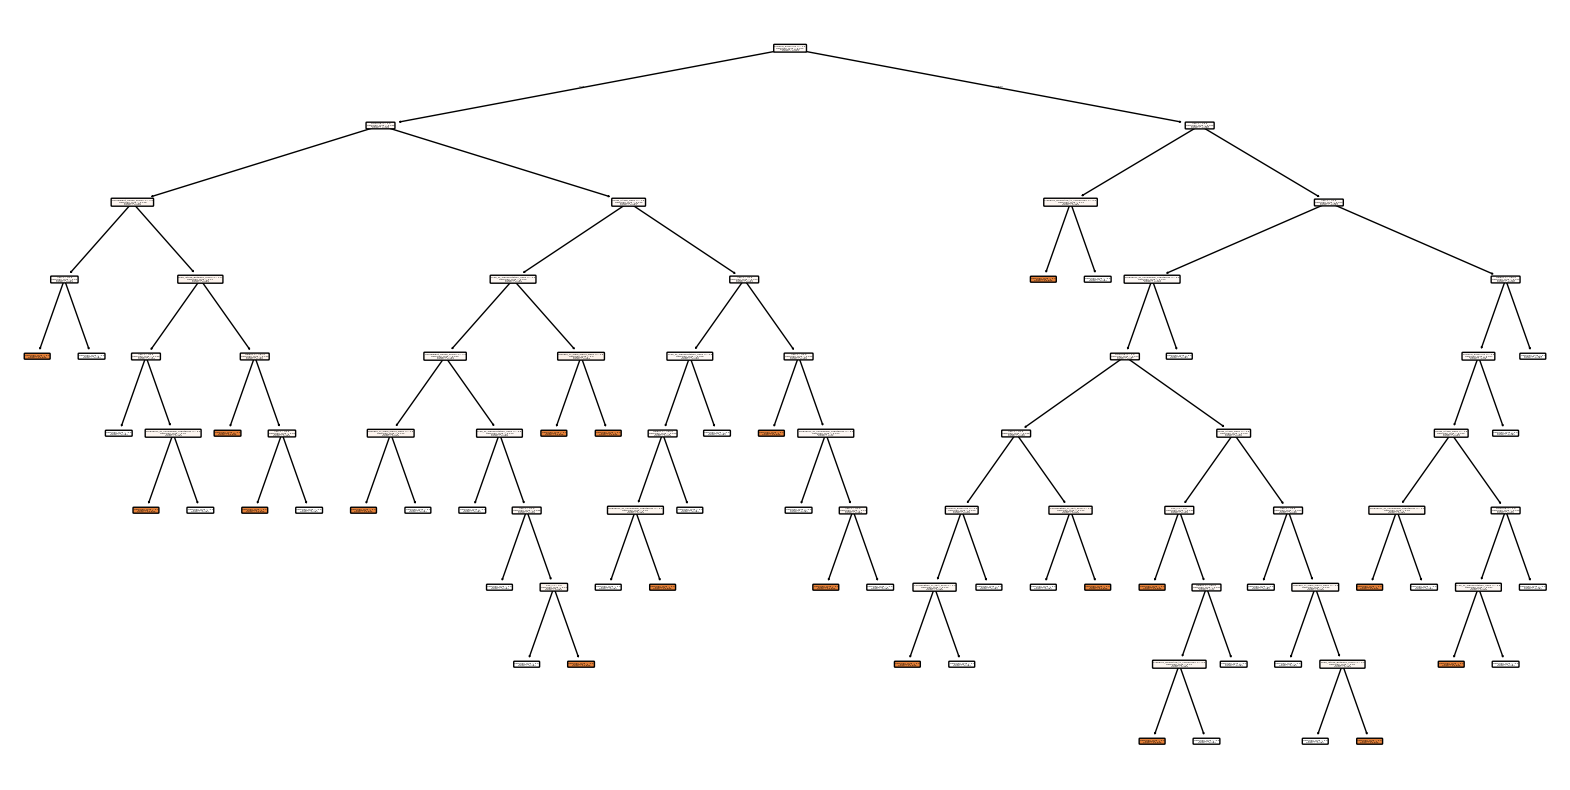

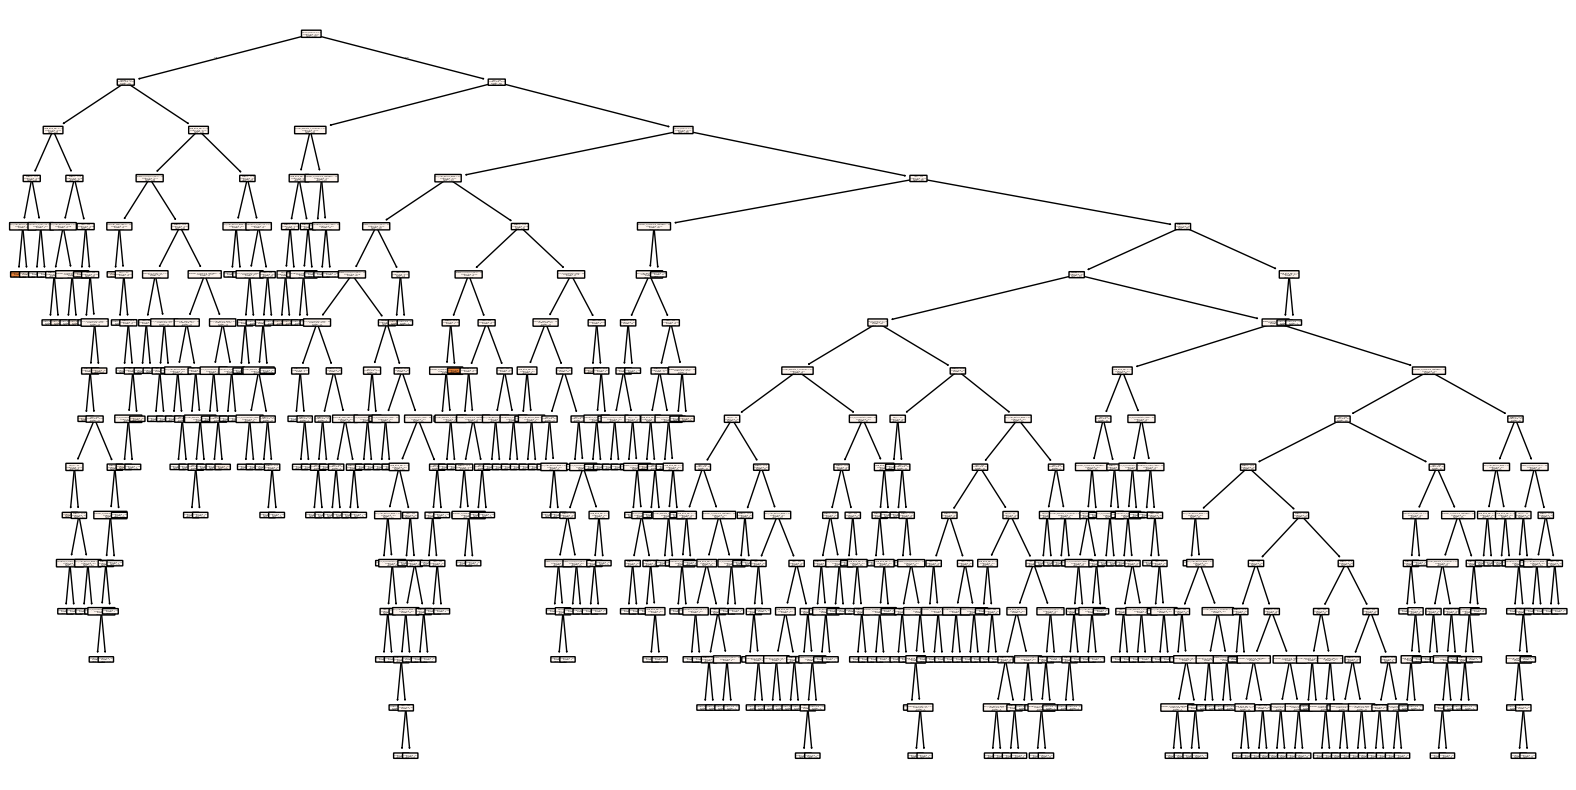

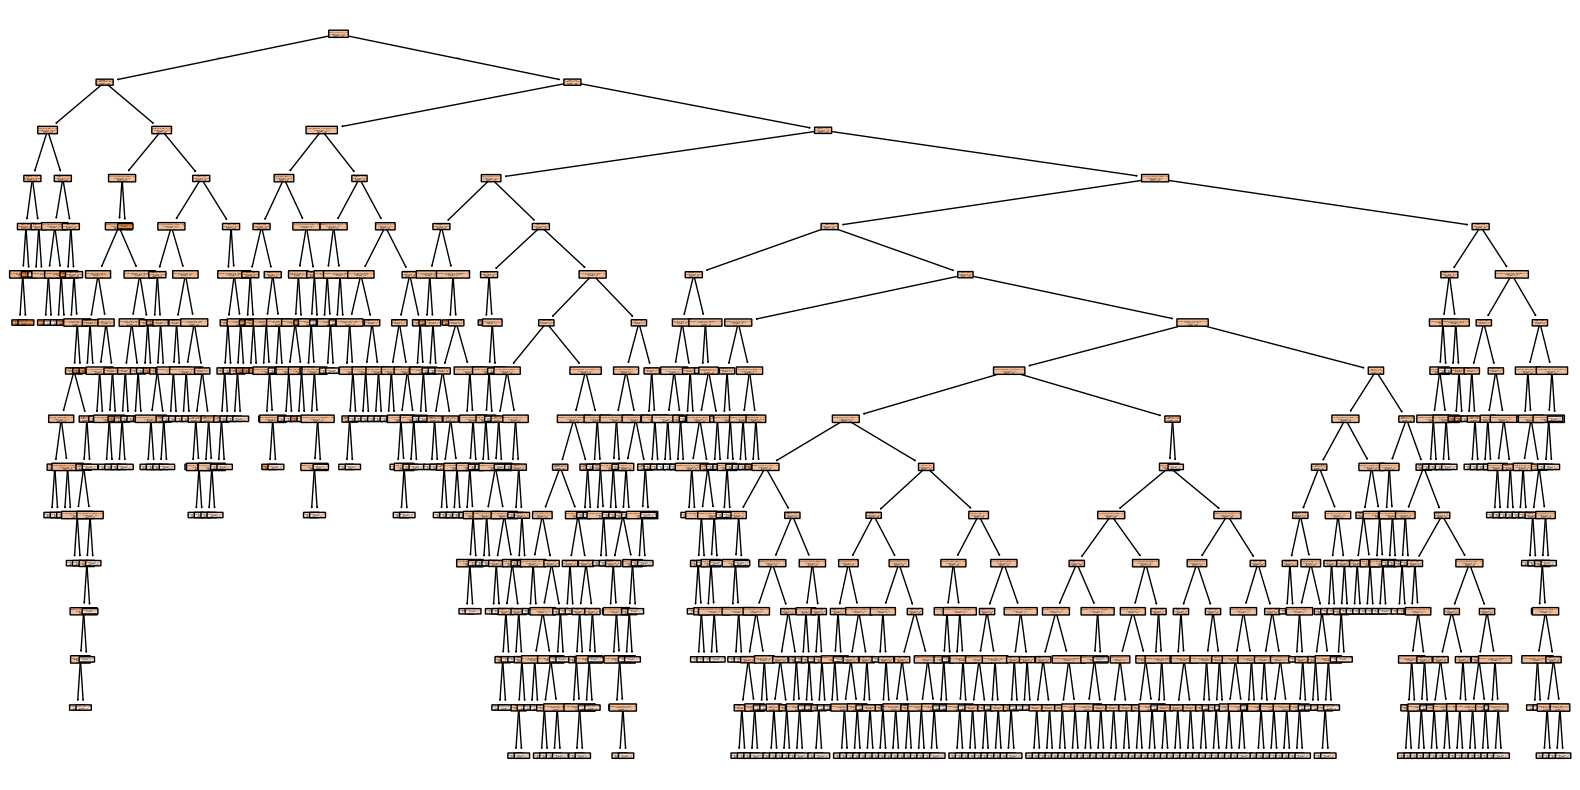

In [ ]:
for i in range(3):
  fig = plt.figure(figsize=(20, 10))
  tree.plot_tree(
      gbc[i][0],
      feature_names=X_train.columns,
      filled=True,
      rounded=True
      )



---



**Вывод**: используя метод градиентного бустинга, мы смогли повысить качество классификации (0.9035) в сравнении с деревом решений (0.8545) по среднему взвешенному. оценили важность признаков для предсказания



---



---



# 4. Для метода градиентного бустинга построим зависимость качества решения (на обучении и скользящем контроле) от числа деревьев.

In [ ]:
n_estimators_values = range(1, 30)

train_accuracies = []
test_accuracies = []
cross_val_scores = []

In [ ]:
max_train, max_test, max_cross = 0, 0, 0
train_tree, test_tree, cross_tree = 0, 0, 0

for n_estimators in n_estimators_values:

    model = GBC(
        n_estimators=n_estimators,
        learning_rate=0.2,
        subsample=0.8,
        max_depth=15,
        random_state=42
        )
    model.fit(X_train, Y_train)

    train_accuracy = accuracy_score(Y_train, model.predict(X_train))
    train_accuracies.append(train_accuracy)

    test_accuracy = accuracy_score(Y_test, model.predict(X_test))
    test_accuracies.append(test_accuracy)

    cross_val_score_mean = np.mean(cross_val_score(model, X, Y))
    cross_val_scores.append(cross_val_score_mean)

    if train_accuracy > max_train:
      max_train = train_accuracy
      train_tree = n_estimators

    if test_accuracy > max_test:
      max_test = test_accuracy
      test_tree = n_estimators

    if cross_val_score_mean > max_cross:
      max_cross = cross_val_score_mean
      cross_tree = n_estimators

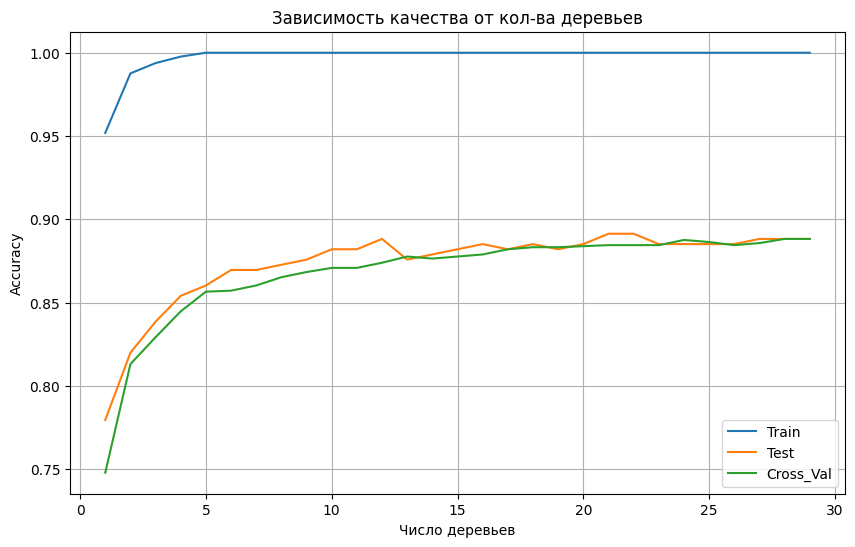

Лучшее качество на трейне (1.000) показывает при кол-ве деревьев = 5.
Лучшее качество на тесте (0.891) показывает при кол-ве деревьев = 21.
Лучшее качество на валидации (0.888) показывает при кол-ве деревьев = 28.


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_values, train_accuracies, label='Train')
plt.plot(n_estimators_values, test_accuracies, label='Test')
plt.plot(n_estimators_values, cross_val_scores, label='Cross_Val')
plt.xlabel('Число деревьев')
plt.ylabel('Accuracy')
plt.title('Зависимость качества от кол-ва деревьев')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print(f'Лучшее качество на трейне ({max_train:.3f}) показывает при кол-ве деревьев = {train_tree}.')
print(f'Лучшее качество на тесте ({max_test:.3f}) показывает при кол-ве деревьев = {test_tree}.')
print(f'Лучшее качество на валидации ({max_cross:.3f}) показывает при кол-ве деревьев = {cross_tree}.')



---



**Вывод**:

- Лучшее качество на тесте (0.891) показывает при кол-ве деревьев = 21.
- Лучшее качество на валидации (0.888) показывает при кол-ве деревьев = 28.



---



---



# 5. Выполним пункт 3-4 для модели случайного леса.

Применяем модель

In [ ]:
from sklearn.ensemble import RandomForestClassifier as RFC

In [ ]:
rf = RFC(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],  # default=100
    'max_depth': [None, 10, 20, 30],  # default=None
    'min_samples_split': [2, 5, 10],  # default=2
    'min_samples_leaf': [1, 2, 4],  # default=1
    'bootstrap': [True, False]  # default=True
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)

best_params = grid_search.best_params_
print(f'Best Parameters: {best_params}')

best_rf = grid_search.best_estimator_
y_test_pred = best_rf.predict(X_test)
test_accuracy = accuracy_score(Y_test, y_test_pred)
print(f'Test Accuracy: {test_accuracy}')

Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Test Accuracy: 0.8944099378881988


In [ ]:
rfc = RFC(
    n_estimators=14,
    random_state=42,
    bootstrap=False
)
rfc.fit(X_train, Y_train)

RandomForestClassifier(bootstrap=False, n_estimators=14, random_state=42)

In [ ]:
print(classification_report(
    Y_test, rfc.predict(X_test),
    target_names=[
        'Underweight', 'Normal', 'Overweight', 'Obesity'
        ], digits=4
    ))

              precision    recall  f1-score   support

 Underweight     1.0000    0.8333    0.9091        12
      Normal     0.9209    0.9412    0.9309       136
  Overweight     0.8621    0.9009    0.8811       111
     Obesity     0.9474    0.8571    0.9000        63

    accuracy                         0.9068       322
   macro avg     0.9326    0.8831    0.9053       322
weighted avg     0.9087    0.9068    0.9069       322



Значимость признаков

In [ ]:
importances = rfc.feature_importances_
feature_imp_df = pd.DataFrame(
    {'Feature': X.columns, 'Importance': importances}
    ).sort_values('Importance', ascending=False)
print(feature_imp_df)

                              Feature  Importance
0                                 Age    0.214121
1                              Height    0.112885
4   Frequency_of_Consuming_Vegetables    0.090056
12        Type_of_Transportation_Used    0.087274
5          Number_of_Main_Meals_Daily    0.085488
10                 Physical_Excercise    0.080176
6           Food_Intake_Between_Meals    0.050108
8                 Liquid_Intake_Daily    0.046980
7                             Smoking    0.040874
11   Schedule_Dedicated_to_Technology    0.040196
14                              Sex_m    0.037739
3            Consumption_of_Fast_Food    0.037410
2             Overweight_Obese_Family    0.029931
13                              Sex_f    0.024307
9       Calculation_of_Calorie_Intake    0.022457


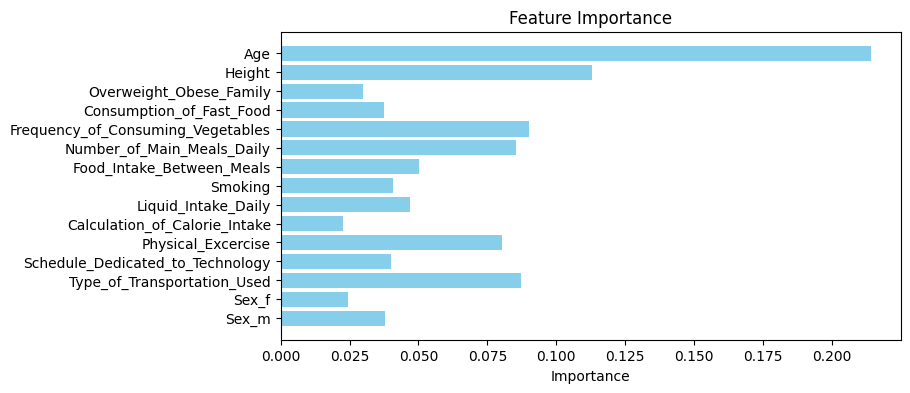

In [ ]:
plt.figure(figsize=(8, 4))
plt.barh(X.columns, importances, color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

Первые три дерева леса

In [ ]:
from sklearn.tree import plot_tree

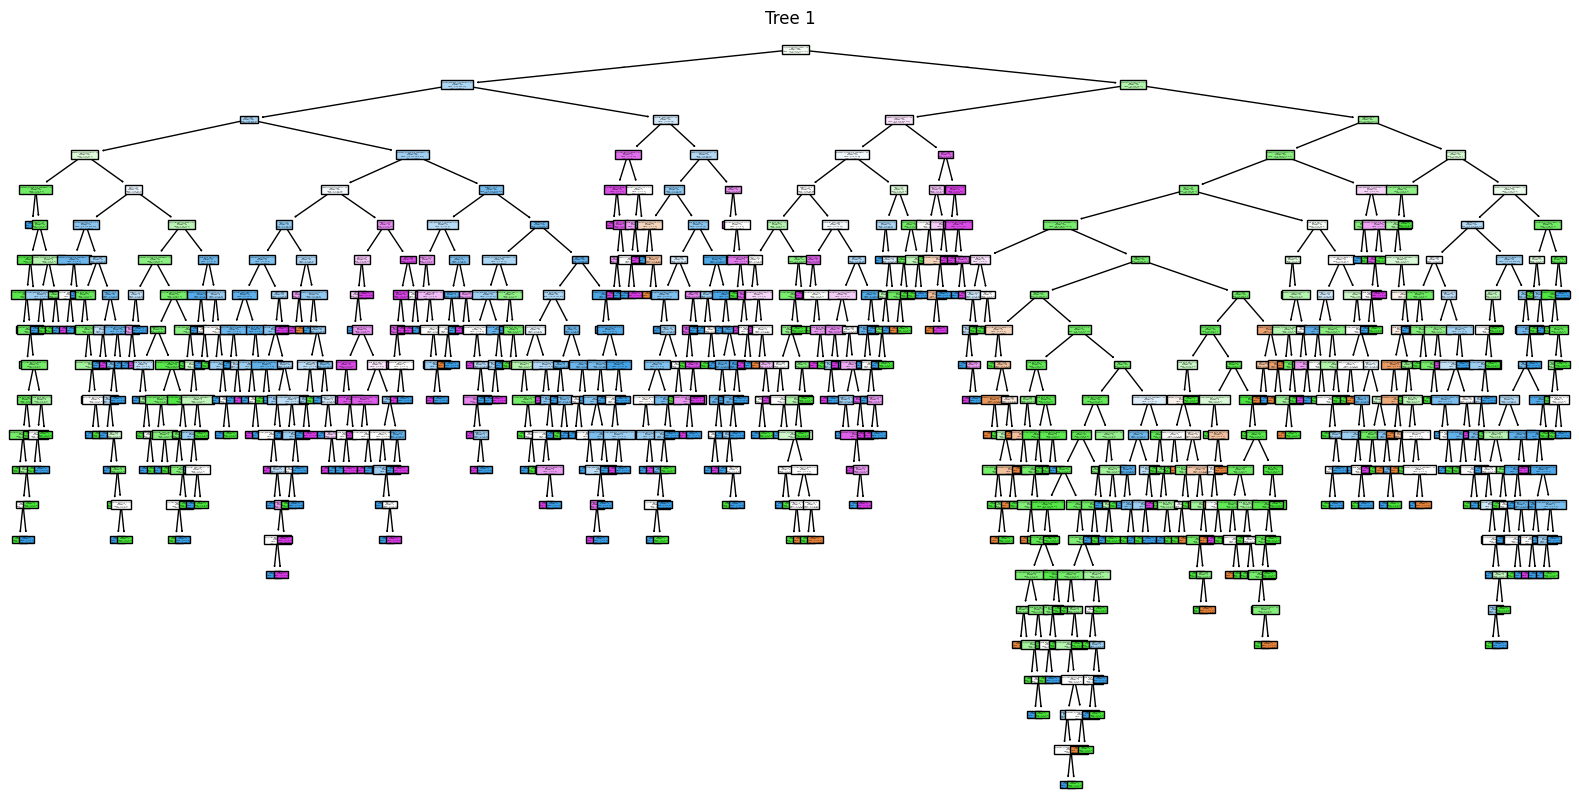

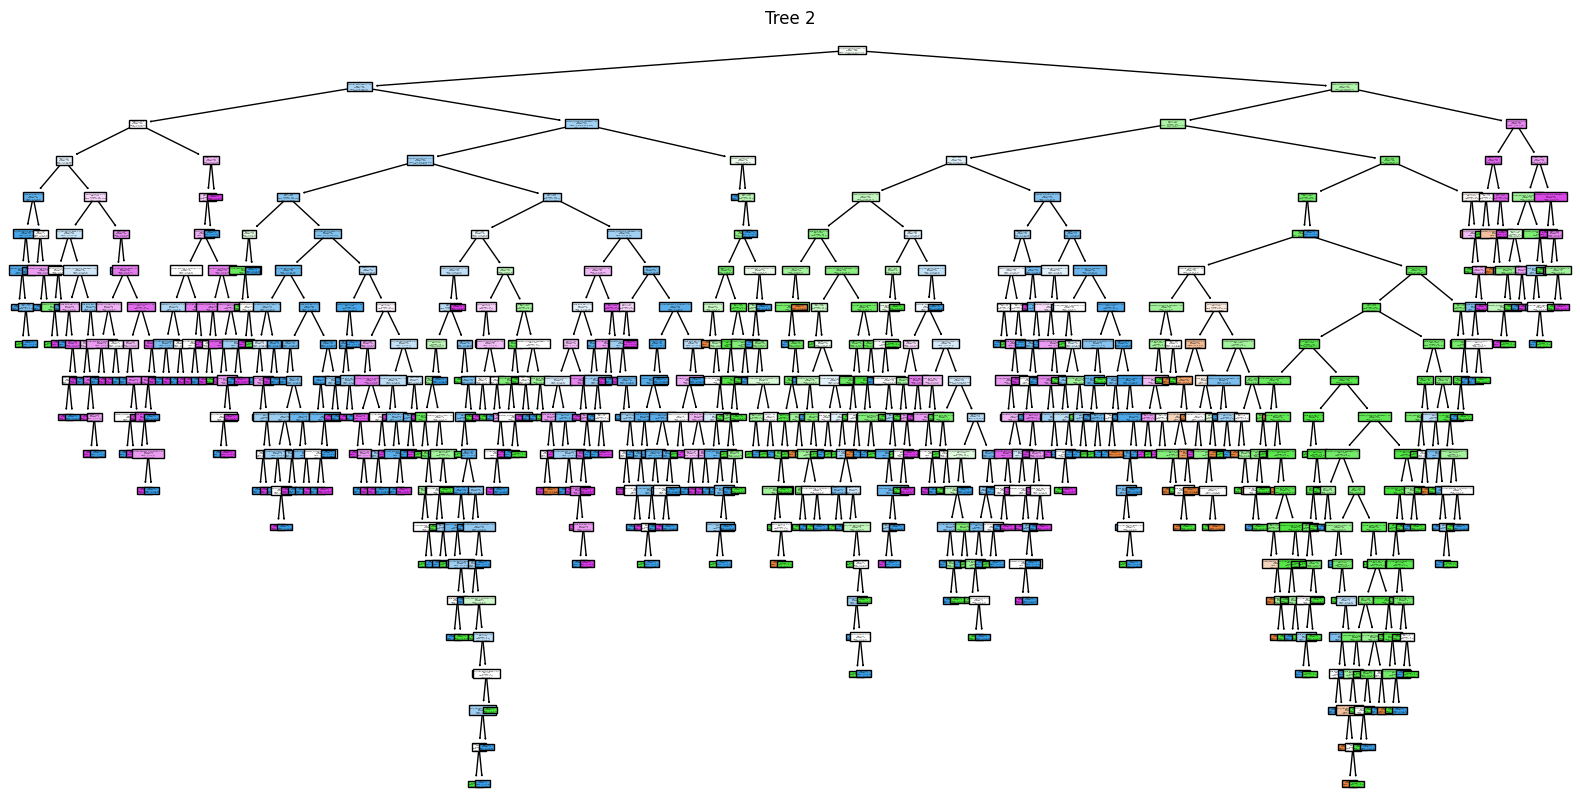

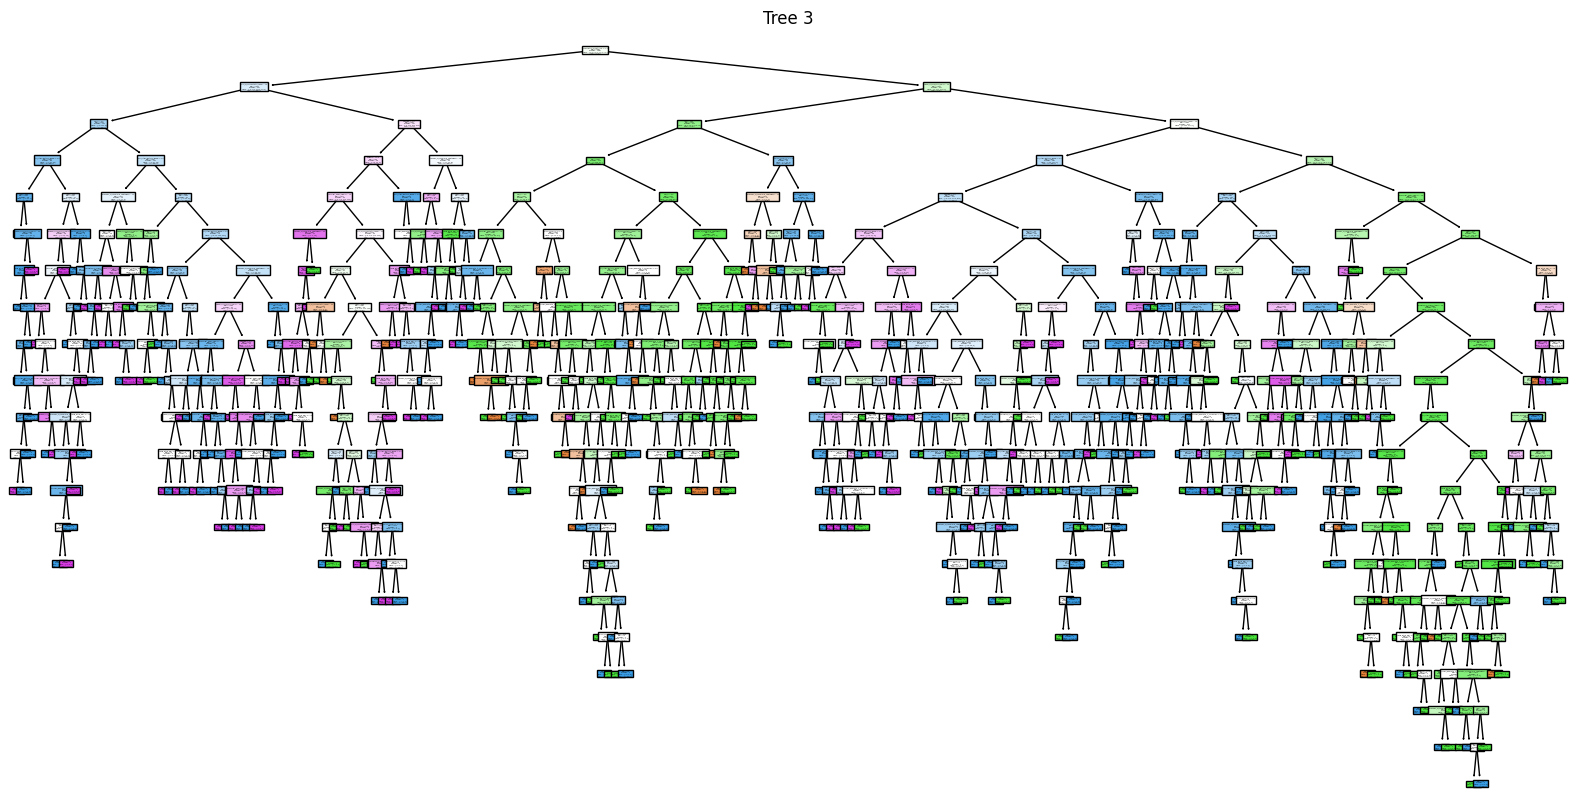

In [ ]:
# Визуализация первых трех деревьев
for i in range(3):
    trees = rfc.estimators_[i]

    plt.figure(figsize=(20, 10))
    plot_tree(
        trees,
        feature_names=X.columns,
        class_names=['Underweight', 'Normal', 'Overweight', 'Obesity'],
        filled=True
    )
    plt.title(f"Tree {i+1}")
    plt.show()

Зависимость качества от кол-ва деревьев

In [ ]:
n_estimators_values = range(1, 200)

train_accuracies = []
test_accuracies = []
cross_val_scores = []

In [ ]:
max_train, max_test, max_cross = 0, 0, 0
train_tree, test_tree, cross_tree = 0, 0, 0

for n_estimators in n_estimators_values:

    model = RFC(
        n_estimators=n_estimators,
        random_state=42,
        bootstrap=False
        )
    model.fit(X_train, Y_train)

    train_accuracy = accuracy_score(Y_train, model.predict(X_train))
    train_accuracies.append(train_accuracy)

    test_accuracy = accuracy_score(Y_test, model.predict(X_test))
    test_accuracies.append(test_accuracy)

    cross_val_score_mean = np.mean(cross_val_score(model, X, Y))
    cross_val_scores.append(cross_val_score_mean)

    if train_accuracy > max_train:
      max_train = train_accuracy
      train_tree = n_estimators

    if test_accuracy > max_test:
      max_test = test_accuracy
      test_tree = n_estimators

    if cross_val_score_mean > max_cross:
      max_cross = cross_val_score_mean
      cross_tree = n_estimators

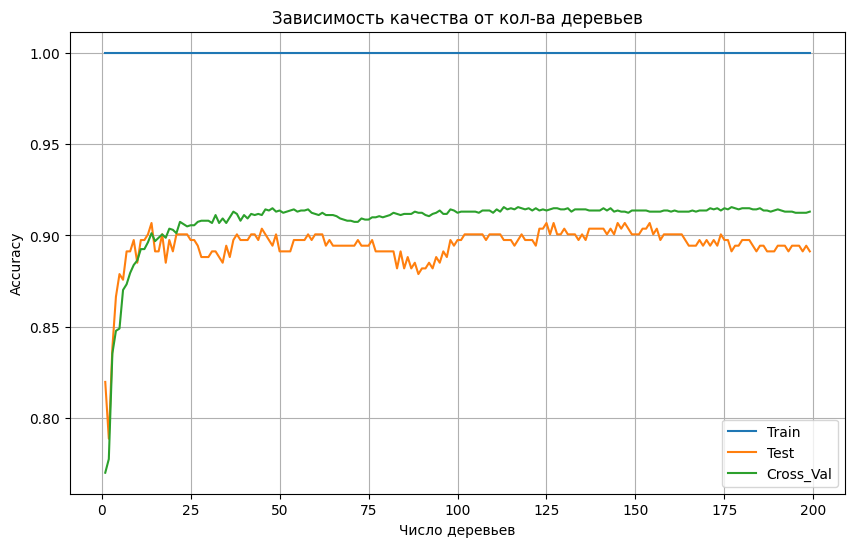

Лучшее качество на трейне (1.000) показывает при кол-ве деревьев = 1.
Лучшее качество на тесте (0.907) показывает при кол-ве деревьев = 14.
Лучшее качество на валидации (0.916) показывает при кол-ве деревьев = 177.


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_values, train_accuracies, label='Train')
plt.plot(n_estimators_values, test_accuracies, label='Test')
plt.plot(n_estimators_values, cross_val_scores, label='Cross_Val')
plt.xlabel('Число деревьев')
plt.ylabel('Accuracy')
plt.title('Зависимость качества от кол-ва деревьев')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print(f'Лучшее качество на трейне ({max_train:.3f}) показывает при кол-ве деревьев = {train_tree}.')
print(f'Лучшее качество на тесте ({max_test:.3f}) показывает при кол-ве деревьев = {test_tree}.')
print(f'Лучшее качество на валидации ({max_cross:.3f}) показывает при кол-ве деревьев = {cross_tree}.')



---



**Вывод**:

Качество моделей:
- дерево решений = 0.855
- градиентный бустинг = 0.904
- случайный лес = 0.907

По оценке качества классификации ГБ и СЛ сопоставимы.



---



---

